## All Imports

In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image

from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, auc
)

## Mount Google Drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')
!unzip /content/drive/MyDrive/dataset.zip -d /content/

Mounted at /content/drive
Archive:  /content/drive/MyDrive/dataset.zip
   creating: /content/dataset/
   creating: /content/dataset/train/
   creating: /content/dataset/train/bird/
  inflating: /content/dataset/train/bird/0.jpg  
  inflating: /content/dataset/train/bird/1.jpg  
  inflating: /content/dataset/train/bird/10.jpg  
  inflating: /content/dataset/train/bird/100.jpg  
  inflating: /content/dataset/train/bird/101.jpg  
  inflating: /content/dataset/train/bird/102.jpg  
  inflating: /content/dataset/train/bird/103.jpg  
  inflating: /content/dataset/train/bird/104.jpg  
  inflating: /content/dataset/train/bird/105.jpg  
  inflating: /content/dataset/train/bird/106.jpg  
  inflating: /content/dataset/train/bird/107.jpg  
  inflating: /content/dataset/train/bird/108.jpg  
  inflating: /content/dataset/train/bird/109.jpg  
  inflating: /content/dataset/train/bird/11.jpg  
  inflating: /content/dataset/train/bird/110.jpg  
  inflating: /content/dataset/train/bird/111.jpg  
  inflati

## Count Images (Proving the Imbalance)

In [3]:
def count_files(directory):
    for root, dirs, files in os.walk(directory):
        if dirs: continue
        print(f"{os.path.basename(root)}: {len(files)} images")

print("Training Data Counts:")
count_files('/content/dataset/train')

Training Data Counts:
bird: 151 images
dog: 299 images
cat: 221 images


## Data Preprocessing & Generators

In [4]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    '/content/dataset/train',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_gen = test_datagen.flow_from_directory(
    '/content/dataset/validation',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False  # Crucial for Evaluation Metrics!
)

Found 671 images belonging to 3 classes.
Found 150 images belonging to 3 classes.


## Model Building Functions

In [5]:
def build_cnn():
    model = models.Sequential([
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dense(3, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

def build_transfer(base_name):
    if base_name == "ResNet50":
        base = tf.keras.applications.ResNet50(input_shape=(224,224,3), include_top=False, weights='imagenet')
    else:
        base = tf.keras.applications.MobileNetV2(input_shape=(224,224,3), include_top=False, weights='imagenet')

    base.trainable = False  # Freeze pretrained weights
    model = models.Sequential([
        base,
        layers.GlobalAveragePooling2D(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(3, activation='softmax')
    ])
    model.compile(
        optimizer=optimizers.Adam(learning_rate=0.0001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

cnn_model     = build_cnn()
resnet_model  = build_transfer("ResNet50")
mobilenet_model = build_transfer("MobileNetV2")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


## Training (The Comparison)

In [14]:
print("Training CNN...")
history_cnn = cnn_model.fit(train_gen, validation_data=test_gen, epochs=20)

print("Training ResNet50...")
history_resnet = resnet_model.fit(train_gen, validation_data=test_gen, epochs=20)

print("Training MobileNetV2...")
history_mobile = mobilenet_model.fit(train_gen, validation_data=test_gen, epochs=20)

Training CNN...
Epoch 1/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 92s 4s/step - accuracy: 0.4322 - loss: 1.0615 - val_accuracy: 0.3467 - val_loss: 1.1249
Epoch 2/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 89s 4s/step - accuracy: 0.4292 - loss: 1.0610 - val_accuracy: 0.3333 - val_loss: 1.1204
Epoch 3/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 91s 4s/step - accuracy: 0.4545 - loss: 1.0328 - val_accuracy: 0.4133 - val_loss: 1.1212
Epoch 4/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 87s 4s/step - accuracy: 0.4441 - loss: 1.0497 - val_accuracy: 0.3333 - val_loss: 1.0971
Epoch 5/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 89s 4s/step - accuracy: 0.4441 - loss: 1.0318 - val_accuracy: 0.3400 - val_loss: 1.2324
Epoch 6/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 89s 4s/step - accuracy: 0.4486 - loss: 1.0345 - val_accuracy: 0.3267 - val_loss: 1.1274
Epoch 7/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 87s 4s/step - accuracy: 0.4769 - loss: 1.0118 - val_accuracy: 0.4400 - val_loss: 1.1767
Epoch 8/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 89s 4s/step - accuracy: 0.4754 - loss: 0.9967 - val_accuracy: 0.

## Save Models to Google Drive

In [16]:
model_dir = '/content/drive/MyDrive/my_ml_models'
os.makedirs(model_dir, exist_ok=True)

def save_model_to_drive(model, model_name, model_dir):
    model_path = os.path.join(model_dir, f'{model_name}.keras')
    model.save(model_path)
    print(f"✅ {model_name} saved to {model_path}")

save_model_to_drive(cnn_model,       'cnn_animal_model',       model_dir)
save_model_to_drive(resnet_model,    'resnet_animal_model',    model_dir)
save_model_to_drive(mobilenet_model, 'mobilenet_animal_model', model_dir)

✅ cnn_animal_model saved to /content/drive/MyDrive/my_ml_models/cnn_animal_model.keras
✅ resnet_animal_model saved to /content/drive/MyDrive/my_ml_models/resnet_animal_model.keras
✅ mobilenet_animal_model saved to /content/drive/MyDrive/my_ml_models/mobilenet_animal_model.keras


## Load a Saved Model

In [8]:
model_dir = '/content/drive/MyDrive/my_ml_models'
mobilenet_loaded_model = load_model(os.path.join(model_dir, 'mobilenet_animal_model.keras'))
print("✅ MobileNetV2 model loaded successfully!")

✅ MobileNetV2 model loaded successfully!


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 10 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


## Single Image Prediction

In [17]:
validation_bird_path = '/content/dataset/validation/bird'
sample_image_path = None

for f_name in os.listdir(validation_bird_path):
    full_path = os.path.join(validation_bird_path, f_name)
    if os.path.isfile(full_path):
        sample_image_path = full_path
        break

if sample_image_path:
    img = image.load_img(sample_image_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) / 255.0

    predictions = mobilenet_loaded_model.predict(img_array)
    class_labels = list(test_gen.class_indices.keys())
    predicted_class = class_labels[np.argmax(predictions)]
    confidence = predictions[0][np.argmax(predictions)] * 100

    print(f"Predicted class: {predicted_class} with {confidence:.2f}% confidence.")
    print("Raw predictions:", predictions)
else:
    print("No sample image found.")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step
Predicted class: dog with 53.00% confidence.
Raw predictions: [[0.24197017 0.22799645 0.5300334 ]]


## Model Evaluation Function

In [18]:
def evaluate_model(model, generator):
    generator.reset()
    y_true = generator.classes
    y_pred_probs = model.predict(generator)
    y_pred = np.argmax(y_pred_probs, axis=1)

    print("Classification Report:")
    print(classification_report(y_true, y_pred, target_names=list(generator.class_indices.keys())))

    cm = confusion_matrix(y_true, y_pred)
    print("Confusion Matrix:\n", cm)

    auc_score = roc_auc_score(y_true, y_pred_probs, multi_class='ovr', average='weighted')
    print("AUC-ROC (weighted, One-vs-Rest):", auc_score)

print("\nCNN Model:")
evaluate_model(cnn_model, test_gen)

print("\nResNet50 Model:")
evaluate_model(resnet_model, test_gen)

print("\nMobileNetV2 Model:")
evaluate_model(mobilenet_model, test_gen)


CNN Model:
5/5 ━━━━━━━━━━━━━━━━━━━━ 17s 3s/step
Classification Report:
              precision    recall  f1-score   support

        bird       0.74      0.46      0.57        50
         cat       0.39      0.18      0.25        50
         dog       0.38      0.72      0.49        50

    accuracy                           0.45       150
   macro avg       0.50      0.45      0.44       150
weighted avg       0.50      0.45      0.44       150

Confusion Matrix:
 [[23  6 21]
 [ 2  9 39]
 [ 6  8 36]]
AUC-ROC (weighted, One-vs-Rest): 0.7067333333333333

ResNet50 Model:
5/5 ━━━━━━━━━━━━━━━━━━━━ 31s 6s/step
Classification Report:
              precision    recall  f1-score   support

        bird       0.00      0.00      0.00        50
         cat       0.50      0.04      0.07        50
         dog       0.34      0.98      0.50        50

    accuracy                           0.34       150
   macro avg       0.28      0.34      0.19       150
weighted avg       0.28      0.34   

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


5/5 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step
Classification Report:
              precision    recall  f1-score   support

        bird       1.00      1.00      1.00        50
         cat       0.96      0.90      0.93        50
         dog       0.91      0.96      0.93        50

    accuracy                           0.95       150
   macro avg       0.95      0.95      0.95       150
weighted avg       0.95      0.95      0.95       150

Confusion Matrix:
 [[50  0  0]
 [ 0 45  5]
 [ 0  2 48]]
AUC-ROC (weighted, One-vs-Rest): 0.9916


## Plotting Confusion Matrices

5/5 ━━━━━━━━━━━━━━━━━━━━ 13s 2s/step

Confusion Matrix for Simple CNN:


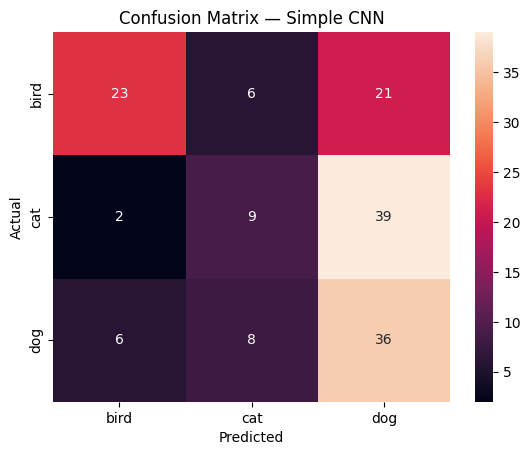

5/5 ━━━━━━━━━━━━━━━━━━━━ 30s 5s/step

Confusion Matrix for ResNet50:


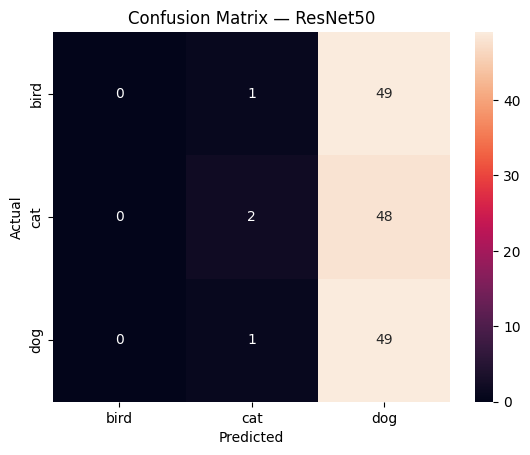

5/5 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step

Confusion Matrix for MobileNetV2:


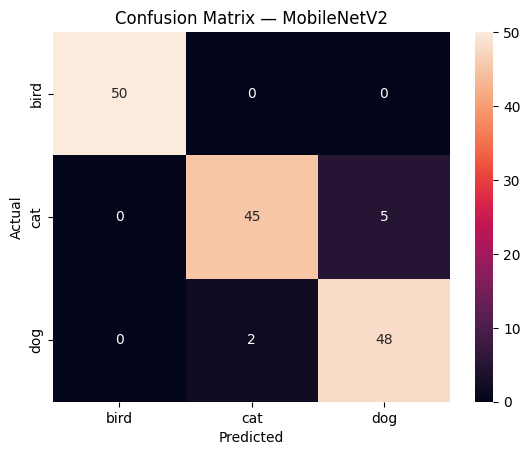

In [19]:
def plot_cm(model, generator, model_name):
    """Resets generator, computes predictions, and plots confusion matrix."""
    generator.reset()
    y_true = generator.classes
    class_names = list(generator.class_indices.keys())
    y_pred = np.argmax(model.predict(generator), axis=1)
    cm = confusion_matrix(y_true, y_pred)

    print(f"\nConfusion Matrix for {model_name}:")
    plt.figure()
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names)
    plt.title(f"Confusion Matrix — {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

plot_cm(cnn_model,       test_gen, "Simple CNN")
plot_cm(resnet_model,    test_gen, "ResNet50")
plot_cm(mobilenet_model, test_gen, "MobileNetV2")

## Plotting ROC Curves

5/5 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step


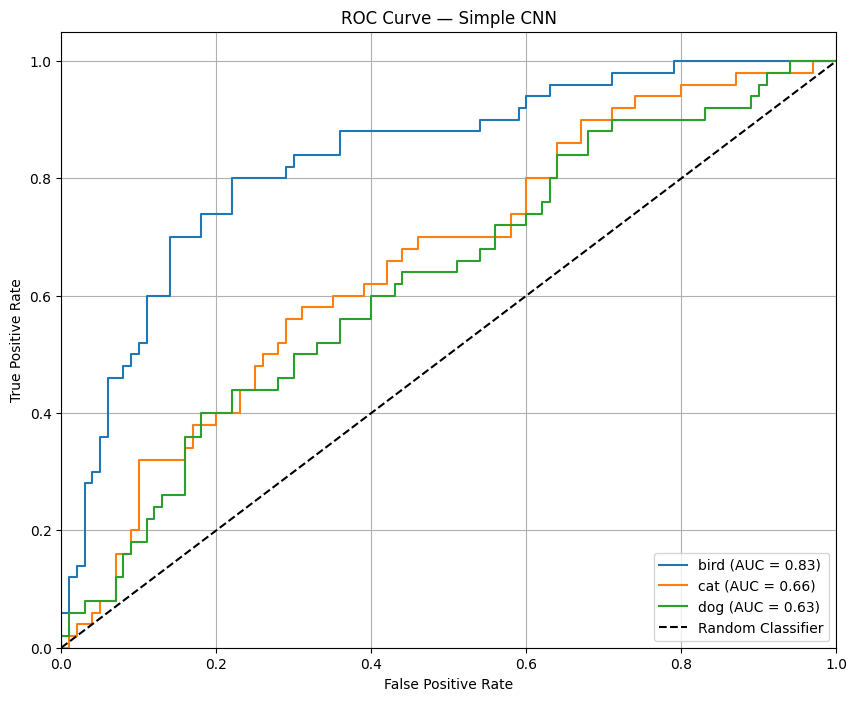

5/5 ━━━━━━━━━━━━━━━━━━━━ 30s 6s/step


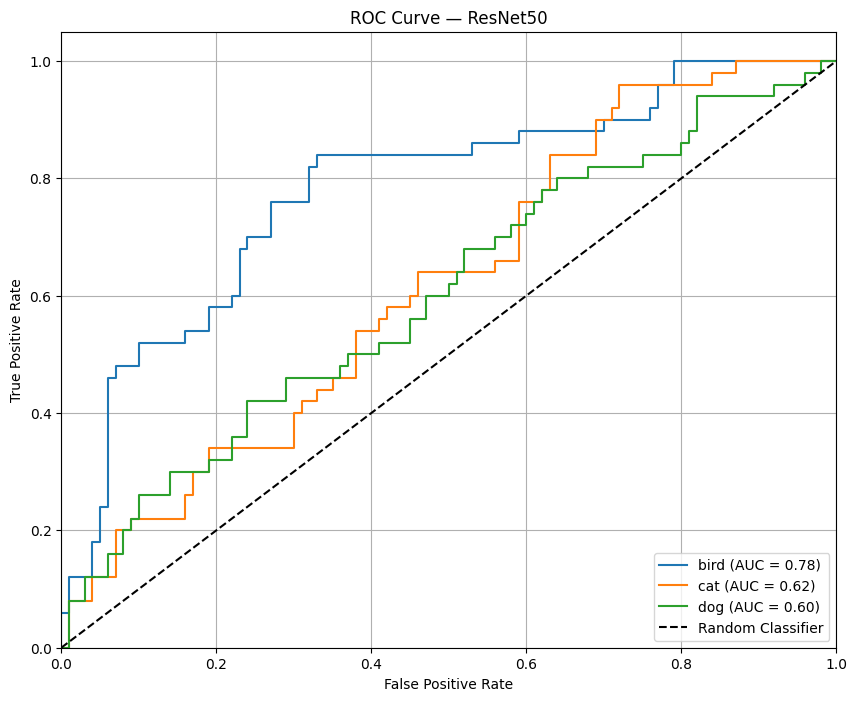

5/5 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step


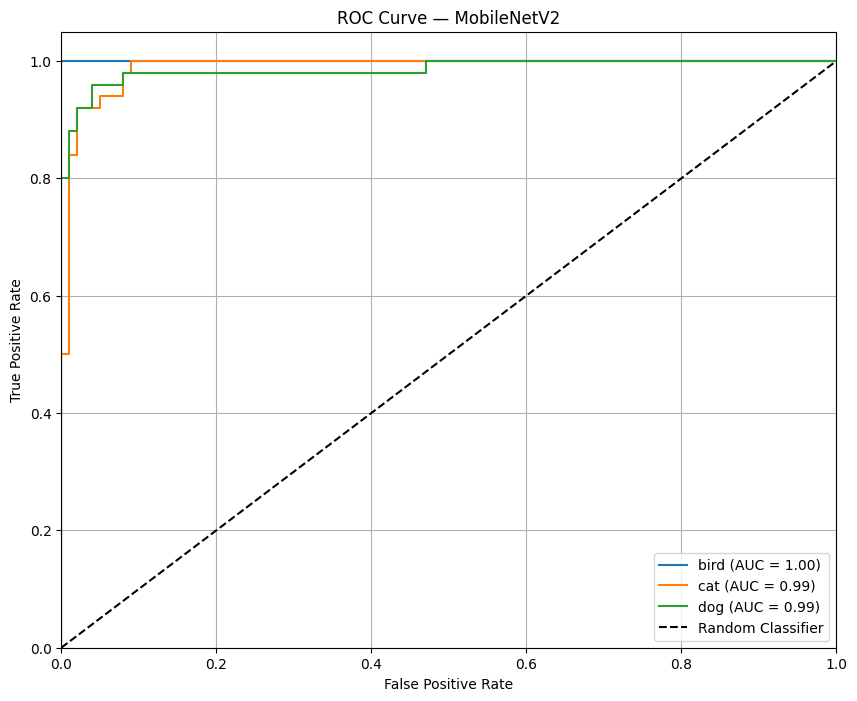

In [20]:
def plot_roc_curve(model, generator, model_name):
    """Resets generator, computes predictions, and plots per-class ROC curves."""
    generator.reset()
    y_true = generator.classes
    class_names = list(generator.class_indices.keys())
    y_pred_probs = model.predict(generator)

    n_classes = len(class_names)
    y_true_one_hot = np.eye(n_classes)[y_true]

    plt.figure(figsize=(10, 8))
    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_true_one_hot[:, i], y_pred_probs[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'{class_names[i]} (AUC = {roc_auc:.2f})')

    plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve — {model_name}')
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()

plot_roc_curve(cnn_model,       test_gen, "Simple CNN")
plot_roc_curve(resnet_model,    test_gen, "ResNet50")
plot_roc_curve(mobilenet_model, test_gen, "MobileNetV2")

## Error Rate Comparison

,Model,Error Rate (%)
0,Simple CNN,54.67%
1,ResNet50,66.00%
2,MobileNetV2,4.67%


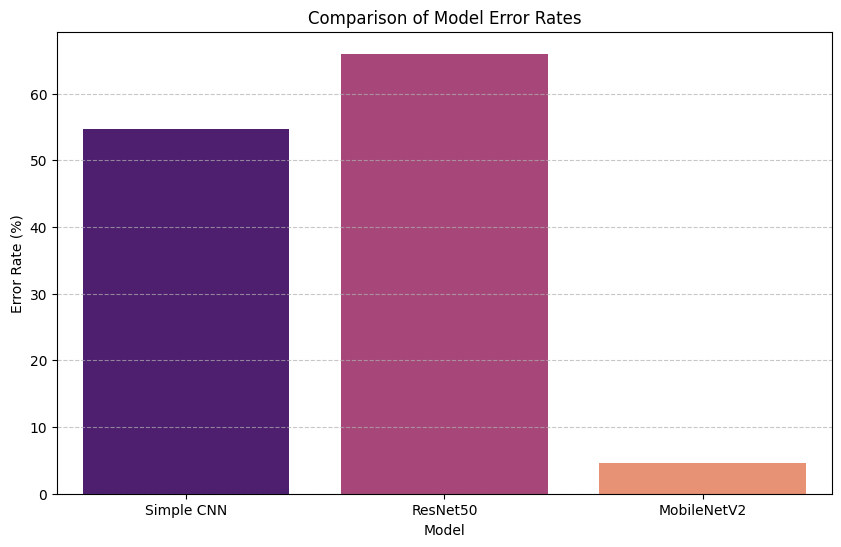

In [21]:
def get_error_rate(model, generator):
    generator.reset()
    loss, accuracy = model.evaluate(generator, verbose=0)
    return 1 - accuracy

error_data = {
    'Model': ['Simple CNN', 'ResNet50', 'MobileNetV2'],
    'Error Rate (%)': [
        get_error_rate(cnn_model, test_gen) * 100,
        get_error_rate(resnet_model, test_gen) * 100,
        get_error_rate(mobilenet_model, test_gen) * 100
    ]
}

df_errors = pd.DataFrame(error_data)
display(df_errors.style.format({'Error Rate (%)': '{:.2f}%'}))

plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='Error Rate (%)', data=df_errors, palette='magma', hue='Model', legend=False)
plt.title('Comparison of Model Error Rates')
plt.ylabel('Error Rate (%)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### ***Final Performance Comparison: Dog-Cat-Bird Classification ***

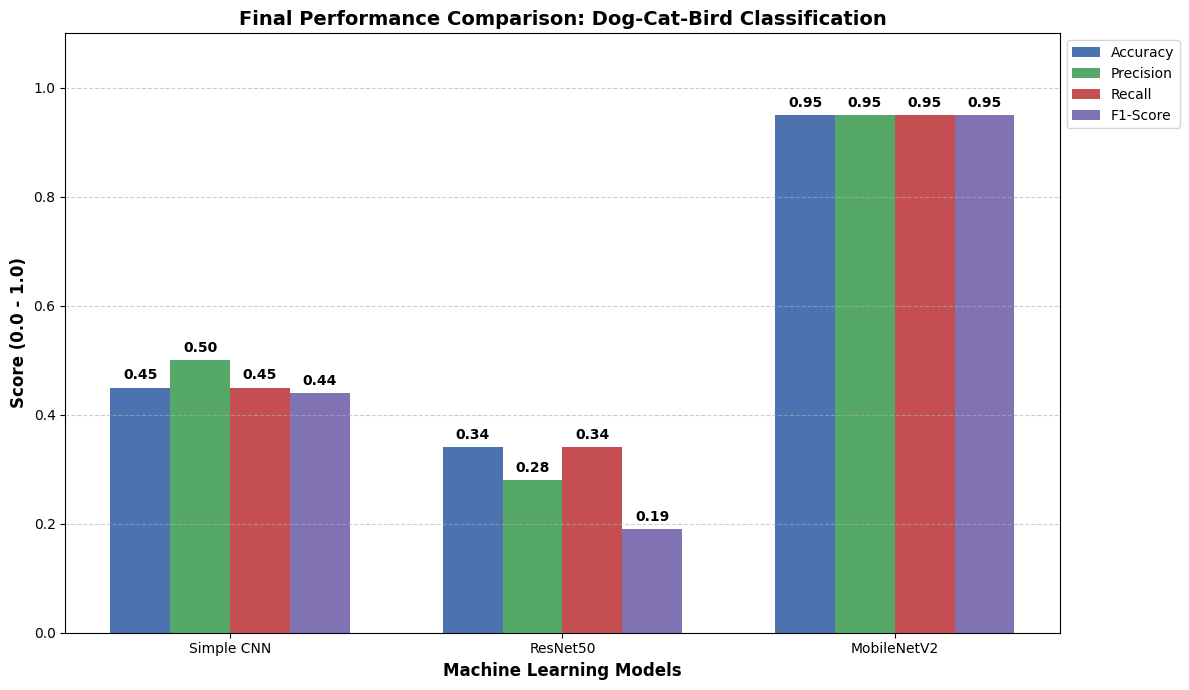

In [2]:

# Data from your final test results
data = {
    'Model': ['Simple CNN', 'ResNet50', 'MobileNetV2'],
    'Accuracy': [0.45, 0.34, 0.95],
    'Precision': [0.50, 0.28, 0.95],
    'Recall': [0.45, 0.34, 0.95],
    'F1-Score': [0.44, 0.19, 0.95]
}

df = pd.DataFrame(data)

# Visualizing
plt.figure(figsize=(12, 7))
index = np.arange(len(df['Model']))
bar_width = 0.18
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
colors = ['#4c72b0', '#55a868', '#c44e52', '#8172b3']

for i, metric in enumerate(metrics):
    bars = plt.bar(index + i * bar_width, df[metric], bar_width, label=metric, color=colors[i])
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                 f'{height:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.xlabel('Machine Learning Models', fontsize=12, fontweight='bold')
plt.ylabel('Score (0.0 - 1.0)', fontsize=12, fontweight='bold')
plt.title('Final Performance Comparison: Dog-Cat-Bird Classification', fontsize=14, fontweight='bold')
plt.xticks(index + bar_width * 1.5, df['Model'])
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.ylim(0, 1.1)

plt.tight_layout()
plt.savefig('final_results_chart.png', dpi=300)
plt.show()